<a href="https://colab.research.google.com/github/argoubizakaria-web/SQL-VideoGame-Tournament-Analysis/blob/main/Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [2]:
Agri = pd.read_csv('/content/sample_data/crop_yield.csv')

In [5]:
Agri.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [13]:
corr_matrix = Agri.corr(numeric_only=True)

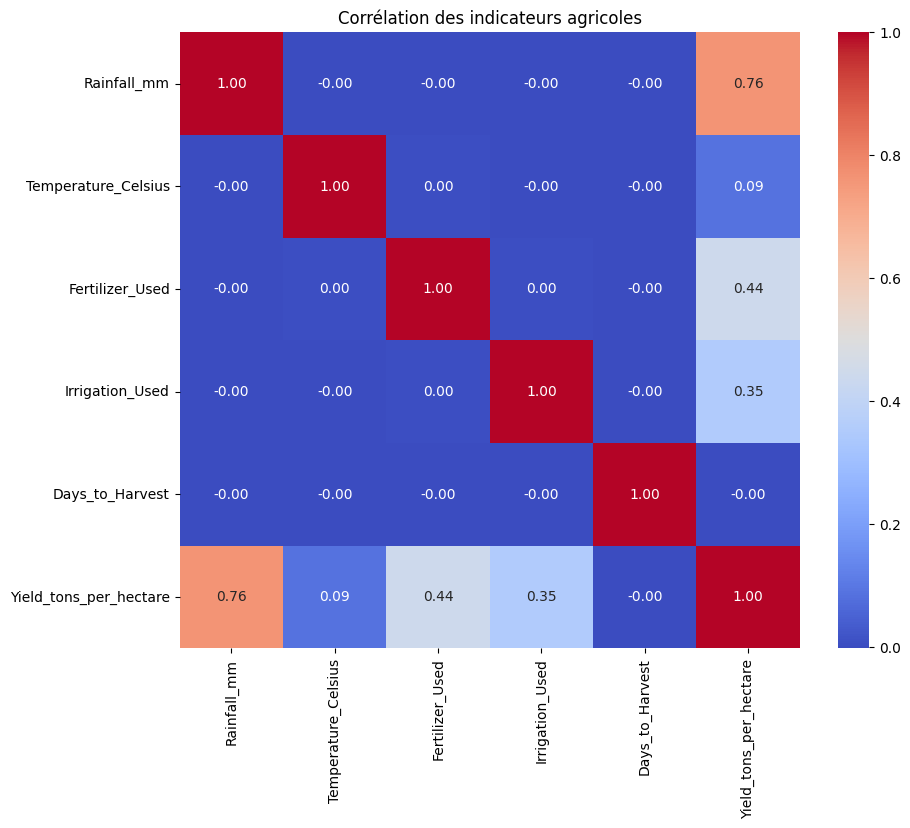

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation des indicateurs agricoles')
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
features = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Fertilizer_Used', 'Irrigation_Used']
X = Agri[features]
y = Agri['Yield_tons_per_hectare']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Convertir True/False en 1 et 0
Agri['Fertilizer_Used'] = Agri['Fertilizer_Used'].astype(int)
Agri['Irrigation_Used'] = Agri['Irrigation_Used'].astype(int)

In [30]:
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=42)

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error

In [39]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [40]:
print(f"--- Évaluation du modèle Agri ---")
print(f"MAE  : {mae:.2f} tonnes")
print(f"RMSE : {rmse:.2f} tonnes")
print(f"R²   : {r2:.2f}")

--- Évaluation du modèle Agri ---
MAE  : 0.44 tonnes
RMSE : 0.55 tonnes
R²   : 0.90


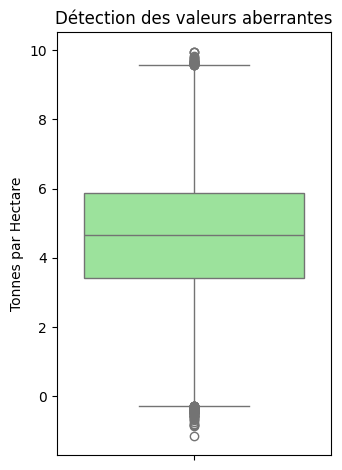

In [41]:
plt.subplot(1, 2, 2)
sns.boxplot(y=Agri['Yield_tons_per_hectare'], color="lightgreen")
plt.title('Détection des valeurs aberrantes')
plt.ylabel('Tonnes par Hectare')

plt.tight_layout()
plt.show()

La Courbe de Validation (Learning Curve)

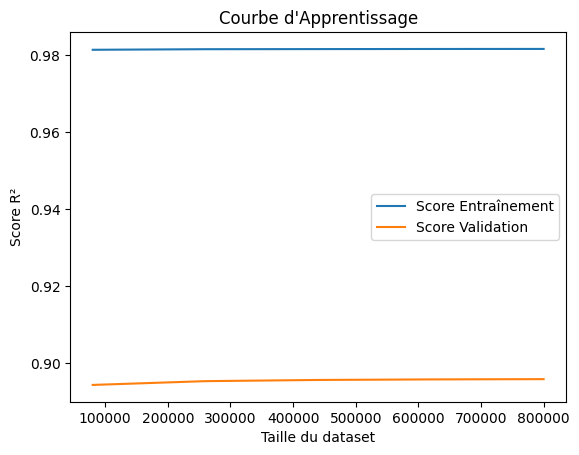

In [43]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=10), X, y, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Score Entraînement')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Score Validation')
plt.title('Courbe d\'Apprentissage')
plt.xlabel('Taille du dataset')
plt.ylabel('Score R²')
plt.legend()
plt.show()